<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/Lab4_PE_RCA929_LEDs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect



# Resume



In [72]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request

## Auxillary functions

In [73]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

def find_root2(V, I, *,
              noise_k=50.0,
              r2_min=0.99,
              min_points=5,
              trim_right=0,
              return_diagnostics=False):
    """
    Stopping voltage V0 by the Du Bridge method, fitting the LINEAR segment
    of sqrt(cathode current) and extrapolating to zero.

    Strategy (grows the window from V=0 leftward):
      1. baseline = anode + dark + leakage, fitted where cathode is off
         (V <= anode_Vmax) and subtracted -> R = cathode current.
      2. On the retarding side (V<0, cathode on), walk from the point
         nearest V=0 toward more negative V, adding points one at a time.
         Keep the LONGEST window whose linear fit of sqrt(R) vs V still has
         R^2 >= r2_min. This stops automatically when the thermal foot
         (left bend) starts to spoil the straight line.
      3. Optionally drop `trim_right` points nearest V=0 first, to discard
         the saturation / space-charge bend at the right end.
      4. V0 = x-intercept of that linear segment (foot is never used).

    No spectrum and no Fowler-DuBridge model required -- one rule:
    "fit the line where it is straight, extrapolate to zero."

    Parameters
    ----------
    noise_k    : cathode counts as "on" when R > noise_k * baseline scatter.
    r2_min     : linearity threshold for growing the window.
    min_points : smallest acceptable linear segment.
    trim_right : how many points nearest V=0 to skip (saturation bend).
    """
    V = np.asarray(V, float); I = np.asarray(I, float)
    order = np.argsort(V); V, I = V[order], I[order]

    base = V <= ANODE_VMAX
    if base.sum() < 3:
        return (np.nan, {"reason": "no baseline region; extend sweep"}) \
            if return_diagnostics else np.nan
    lr = linregress(V[base], I[base])
    R = I - (lr.slope * V + lr.intercept)
    noise = np.std(R[base])

    on = (R > noise_k * noise) & (V < NORMPOINT) & (V > ANODE_VMAX)
    if on.sum() < min_points + trim_right:
        return (np.nan, {"reason": "too few cathode points", "baseline": lr}) \
            if return_diagnostics else np.nan

    xv = V[on]; yv = np.sqrt(R[on])
    # sort from V=0 (right) toward negative (left)
    idx = np.argsort(xv)[::-1]
    xs, ys = xv[idx], yv[idx]
    if trim_right:
        xs, ys = xs[trim_right:], ys[trim_right:]

    # grow window from the right; keep the longest with R^2 >= r2_min
    best_n, best_fit = 0, None
    for n in range(min_points, len(xs) + 1):
        f = linregress(xs[:n], ys[:n])
        if f.rvalue**2 >= r2_min:
            best_n, best_fit = n, f
        # once it has been good and then drops, we can stop early
        elif best_n >= min_points and f.rvalue**2 < r2_min:
            break
    if best_fit is None:                       # never linear enough -> longest run
        best_n = len(xs); best_fit = linregress(xs, ys)

    V0 = -best_fit.intercept / best_fit.slope
    if return_diagnostics:
        seg = idx[trim_right: trim_right + best_n]
        return V0, {"anode_fit": lr, "noise": noise, "cathode_current": R,
                    "cathode_mask": on, "fit_x": xs[:best_n], "fit_y": ys[:best_n],
                    "cathode_fit": best_fit, "r2": best_fit.rvalue**2, "best_n": best_n,
                    "xv": xv, "yv":yv}
    return V0




#Volt-ampere curve


# Dark and Anode current

In [74]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/LED/'
NORMPOINT = 0 #V
ANODE_VMAX = -1.5 #V





(0.0, 0.0021235433162798637)

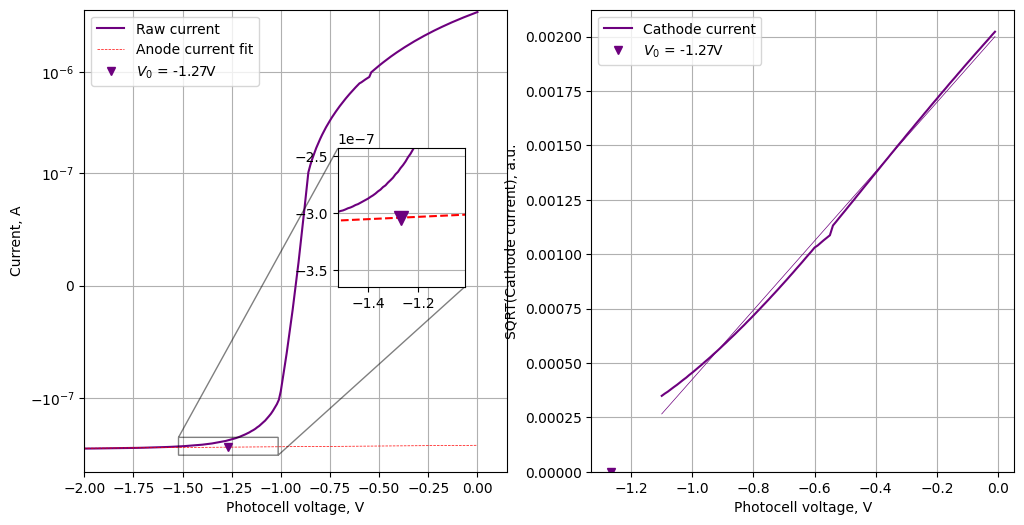

In [75]:
# example
fig, ax = plt.subplots(1, 2, figsize=(12,6))
name, wl = 'RCA929', 390

color = wavelength_to_color(wl)
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)
wls = np.unique(WL)
mask = (WL == wl)
V = V[mask]
I = I[mask]
V0, debug = find_root2(V, I, return_diagnostics=True)
anode_fit = debug['anode_fit']
ax[0].plot(V, I, color=color, label='Raw current')
ax[0].plot(V, anode_fit.slope * V + anode_fit.intercept, color='red', lw=0.5, ls='--', label='Anode current fit')
ax[0].plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
ax[0].set_xlabel('Photocell voltage, V')
ax[0].set_ylabel('Current, A')
ax[0].grid()
ax[0].set_xlim(left=-2)
ax[0].set_yscale('symlog', linthresh=1e-7)
ax[0].legend()

axins = ax[0].inset_axes([0.6, 0.4, 0.3, 0.3]) # [x, y, width, height] in axes coordinates
axins.plot(V, I, color=color)
axins.plot(V, anode_fit.slope * V + anode_fit.intercept, color='red', ls='--')
I0 = anode_fit.slope * V0 + anode_fit.intercept
axins.plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, ms=10)

axins.set_xlim(V0*1.2, V0*0.8)
axins.set_ylim(I0*1.2,I0*0.8)
axins.grid(True)
ax[0].indicate_inset_zoom(axins, edgecolor="black")

#
on = debug['cathode_mask']
xv, yv, cathode_fit = debug['xv'], debug['yv'], debug['cathode_fit']
ax[1].plot(xv, yv, '-', color=color, label='Cathode current')
ax[1].plot(V0, 0, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
ax[1].plot(xv, cathode_fit.slope * xv + cathode_fit.intercept, color=color, lw=0.5)
ax[1].set_xlabel('Photocell voltage, V')
ax[1].set_ylabel('SQRT(Cathode current), a.u.')
ax[1].grid()
ax[1].legend()
ax[1].set_ylim(bottom=0)


<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1491/609303503.py:64: SyntaxWarning: invalid escape sequence '\s'
  ax[2].set_ylabel('Du Bridge, $\sqrt{I}$ a.u.')
/tmp/ipykernel_1491/609303503.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


RCA929 too few cathode points
# wavelength V0
390.0 1.267
 400.0 1.257
 420.0 1.183
 500.0 0.791
 520.0 0.683
 540.0 0.631
 560.0 0.527
 


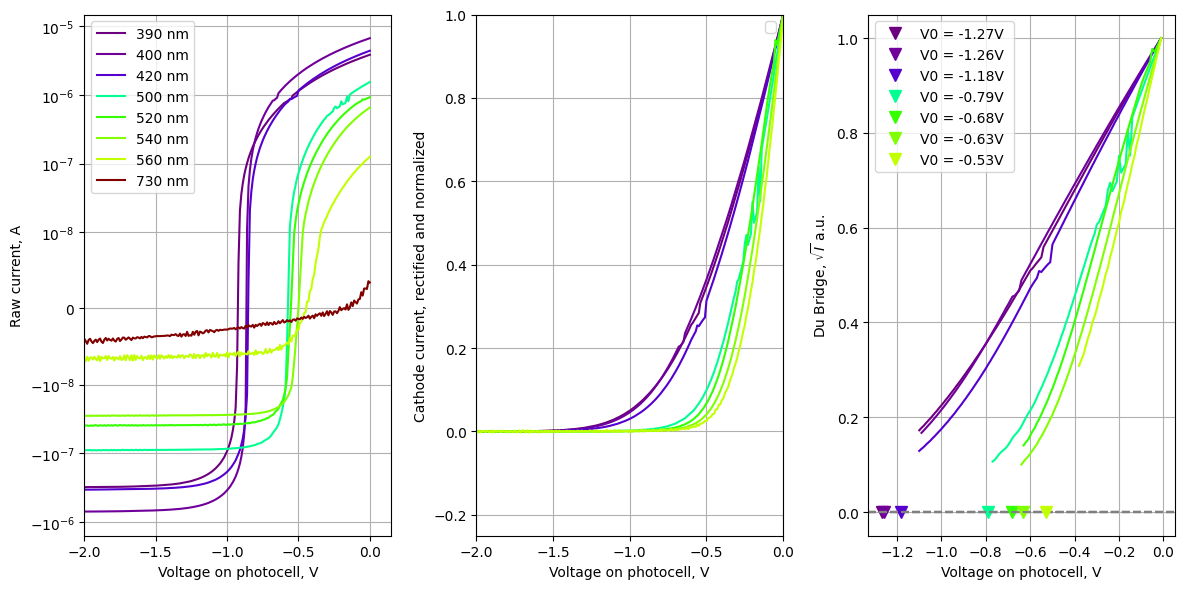

In [85]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))
plt.grid()

data = '# wavelength V0\n'

name = 'RCA929'

url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)

for i, wl in enumerate(np.unique(WL)):
  color= wavelength_to_color(wl)
  opacity = 1
  mask = WL==wl
  Im = I[mask]
  Vm = V[mask]

  # (1) Raw VAC

  ax[0].plot(Vm, Im, '-',  color=color, label=f'{wl:.0f} nm')
  ax[0].set_xlabel('Voltage on photocell, V');
  ax[0].set_ylabel('Raw current, A')
  ax[0].set_yscale('symlog', linthresh=1e-8)
  ax[0].set_xlim(left=-2)
  ax[0].legend()
  ax[0].grid(True)

  # (2) остаток = катодный ток
  # Find points where current I crosses zero current line
  V0, d = find_root2(Vm, Im,  return_diagnostics=True)
  if np.isnan(V0):
    print(name, d['reason'])
    continue
  # diagnostics
  R = d['cathode_current']
  on = d['cathode_mask']
  xv, yv = d['xv'], d['yv']
  cathode_fit = d['cathode_fit']
  # систематика от выбора окна (для погрешности в отчёте)
  data += f'{wl} {-V0:.3f}\n '
  normalization_parameter = np.max(R[Vm <= NORMPOINT])
  Im /= normalization_parameter
  R /= normalization_parameter
  ax[1].plot(Vm, R, '-', ms=2, color=color)
  #ax[1].plot(V0, 0, 'v', ms=8, color=color, label=f'V0 = {V0:.2f}V ')
  #ax[1].axvline(V0, color='#e08000', ls='--', label=f'V0 = {V0:.2f} В')
  ax[1].set_xlim(-2, 0.);
  ax[1].set_ylim(-0.25, 1)
  ax[1].set_xlabel('Voltage on photocell, V');
  ax[1].set_ylabel('Cathode current, rectified and normalized')
  ax[1].grid(True)
  ax[1].legend()

  # (3) Дю-Бридж: sqrt(R) vs V
  xv, yv = d['xv'], d['yv'];
  normalization_parameter = np.max(yv)
  yv /= normalization_parameter
  ax[2].axhline(0, color='gray', ls='--')
  ax[2].plot(V0, 0, 'v', ms=8, color=color, label=f'V0 = {V0:.2f}V ')
  ax[2].plot(xv, yv, '-', ms=2, color=color)
  ax[2].set_xlabel('Voltage on photocell, V');
  ax[2].set_ylabel('Du Bridge, $\sqrt{I}$ a.u.')
  ax[2].grid(True)
  ax[2].legend()
plt.tight_layout()

print(data)

In [77]:
data.splitlines()

['# wavelength V0',
 '390.0 1.267',
 ' 400.0 1.257',
 ' 420.0 1.183',
 ' 500.0 0.791',
 ' 520.0 0.683',
 ' 540.0 0.631',
 ' 560.0 0.527',
 ' ']

# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_1491/2546231385.py:6: RuntimeWarning: divide by zero encountered in divide
  return c * h/ e / energy  * 1e9


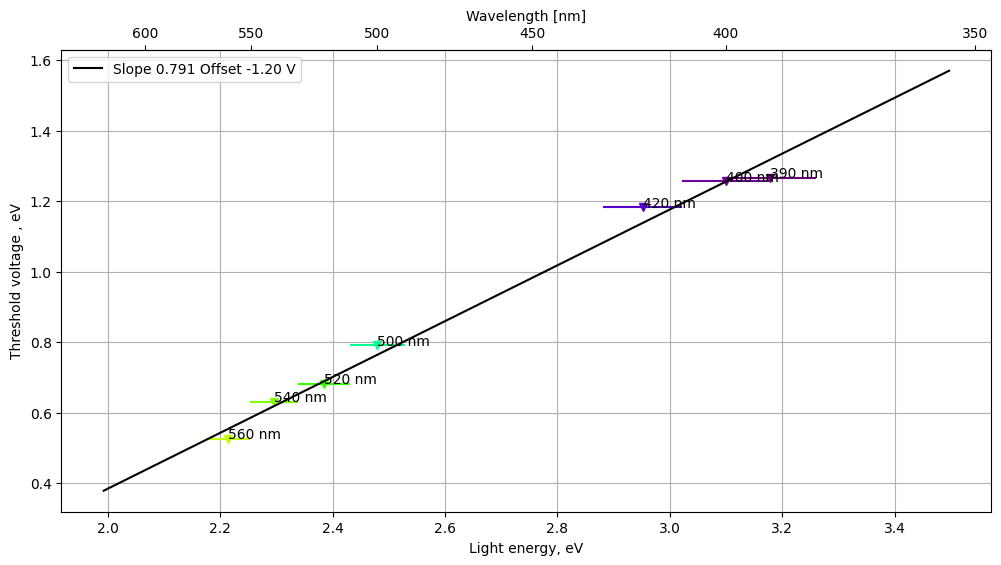

In [87]:
def wl2E(wl):
    return c * h / e / (wl *1e-9)


def E2wl(energy):
    return c * h/ e / energy  * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(wl2E, E2wl))
secax.set_xlabel('Wavelength [nm]')


wl, V0 = np.genfromtxt(data.splitlines()).T



relative_error = 10 / wl #

nu = c / (wl * 1e-9)
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
fit = linregress(V0, energy)
slope = 1 /fit.slope
offset = - fit.intercept / fit.slope




for i in range(len(V0)):
  #if wl[i] == 730:
  #  continue
  color = wavelength_to_color(wl[i])
  plt.errorbar( energy[i], V0[i], yerr=0, xerr=energy_err[i], ls='', color=color)
  plt.plot( energy[i], V0[i], marker='v', color=color)
  plt.annotate(f'{wl[i]:.0f} nm', (energy[i], V0[i]))

en_dense = np.linspace(np.min(energy)*0.9, np.max(energy)*1.1)

plt.plot(en_dense, en_dense * slope + offset, color='black',\
         label=rf'Slope {slope:.3f} Offset {offset:.2f} V')
#plt.plot(en_dense, en_dense , color='lightgray', label=f'Expected slope 1.0')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light energy, eV')
plt.ylabel(r'Threshold voltage , eV')
plt.legend()
plt.show()